# Callbacks

**Goal**: To build a classifier model that predicts the crop disease on images of cassva plants from Uganda. The project uses transfer learning, where a model trained for a task is reused as the starting point for a model on a different task. The project also delves into callbacks, specifically focusing on Learning Rate Scheduling, Checkpointing, and Early Stopping to enhance the training process of the model.

**Objectives**
- Read in data with multiple classes.
- Transform data and prepare it for training.
- Use Transfer Learning to train a classifier model on cassava images.
- Improve training by implementing various callbacks. 
- Prepare a submission for the competition. 

### 1. Setup and Data Preparation

In [17]:
import os 

import matplotlib
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import PIL
import torch
import torch.nn as nn 
import torch.optim as optim 
import torchinfo
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, models, transforms
from tqdm import tqdm

In [20]:
print("torch version: ", torch.__version__)
print("torchvision version: ", torchvision.__version__)
print("torchinfo version: ", torchinfo.__version__)
print("numpy version: ", np.__version__)
print("matplotlib version: ", matplotlib.__version__)

!python --version

torch version:  2.5.1+cpu
torchvision version:  0.20.1+cpu
torchinfo version:  1.8.0
numpy version:  1.26.3
matplotlib version:  3.8.3
Python 3.12.1


- Check if GPU is available and set the device accordingly:

In [21]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Assign data_dir path**

In [22]:
data_dir = os.path.join('data_p2', 'data_undersampled', 'train')

print("Data Directory:", data_dir)

Data Directory: data_p2\data_undersampled\train


**List Class Names**

In [23]:
classes = os.listdir(data_dir)

print("List of classes:", classes)

List of classes: ['cassava-bacterial-blight-cbb', 'cassava-brown-streak-disease-cbsd', 'cassava-green-mottle-cgm', 'cassava-healthy', 'cassava-mosaic-disease-cmd']


**Standardizing the image**
- Convert any greyscale images to RGB format with a custom class.
- Resize the image, so that they are all the same size (224 X 224).
- Convert the image to a Tensor of pixel values.
- Normalize the data. 

In [24]:
class ConvertToRGB(object):
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

**Transformation Pipeline**

In [25]:
transform_normalized = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean = (0.4326, 0.4953, 0.3120), 
                             std = (0.2178, 0.2214, 0.2091))
    ]
)

print(type(transform_normalized))
print("----------------")
print(transform_normalized)

<class 'torchvision.transforms.transforms.Compose'>
----------------
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.4326, 0.4953, 0.312), std=(0.2178, 0.2214, 0.2091))
)


**Normalize dataset**

In [26]:
normalized_dataset = datasets.ImageFolder(root=data_dir, 
                                         transform=transform_normalized)


print('Length of dataset:', len(normalized_dataset))

Length of dataset: 8180


**Training and Validation Split**

In [27]:
g = torch.Generator()
g.manual_seed(42)

train_dataset, val_dataset = random_split(normalized_dataset, [0.8, 0.2], generator=g)

print("Length of training dataset:", len(train_dataset))
print("Length of validation dataset:", len(val_dataset))

percent_train = np.round(100 * len(train_dataset) / len(normalized_dataset), 2)
percent_val = np.round(100 * len(val_dataset) / len(normalized_dataset), 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Length of training dataset: 6544
Length of validation dataset: 1636
Train data is 80.0% of full data
Validation data is 20.0% of full data


**Training Data Distribution**

  0%|          | 0/6544 [00:00<?, ?it/s]

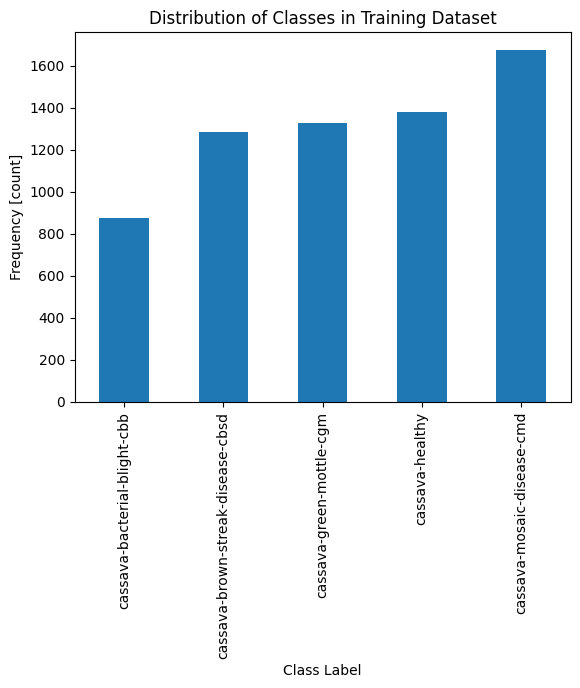

In [29]:
from training import class_counts

train_counts = class_counts(train_dataset)

# Make a bar chart from the function output
train_counts.sort_values().plot(kind='bar')
# Add axis labels and title
plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Distribution of Classes in Training Dataset");

**Validation Data Distribution**

  0%|          | 0/1636 [00:00<?, ?it/s]

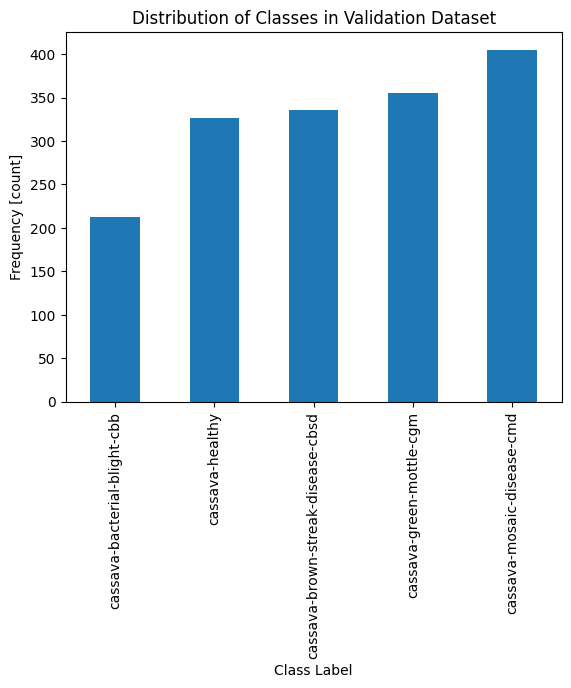

In [30]:
val_counts = class_counts(val_dataset)

# Make a bar chart from the function output
val_counts.sort_values().plot(kind='bar')
# Add axis labels and title
plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Distribution of Classes in Validation Dataset");

**Training and Validation Loaders**

In [31]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(type(train_loader))
print(type(val_loader))

<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.utils.data.dataloader.DataLoader'>


### 2. Model Selection for Transfer Learning**

**ResNet50 Model Definition**

In [32]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**Model Parameter Locking**

In [33]:
# Freeze the models weights
for params in model.parameters():
    params.requires_grad = False
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**Final Layer Features**

In [34]:
# Compute the number of features going into the last layer of the original model.
in_feat = model.fc.in_features

print(in_feat)

2048


We can now change the last layer (layer model.fc) to:
- a dense layer with 256 neurons
- followed by ReLU activation
- then add p=0.5 of Dropout
- followed by the output layer with 5 neurons (because our data has 5 classes)

In [35]:
# Modify Final Layer
modified_last_layer = nn.Sequential()

modified_last_layer.append(nn.Linear(in_feat, 256))

relu = nn.ReLU()
modified_last_layer.append(relu)

modified_last_layer.append(nn.Dropout(p=0.5))

linear = nn.Linear(256, 5)
modified_last_layer.append(linear)

model.fc = modified_last_layer

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### 3. Training the Model

**Set Loss and Optimizer**

In [36]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), weight_decay=1e-4)

print(loss_fn)
print("----------------------")
print(optimizer)

CrossEntropyLoss()
----------------------
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


**Assign Model to Device**

In [37]:
# Place model on device
model.to(device)
print(next(model.parameters()).device)

cpu


**Define Input Size**

In [38]:
height = 224
width = 224

summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 5]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]   

**Training the Model with Callbacks**

We'll implement three key callbacks:

- **Learning Rate Scheduling:** Adjusts the learning rate over time, which can lead to better model performance.
- **Early Stopping:** Halts training when the model's performance stops improving, which prevents overfitting. We'll stop if validation loss doesn't improve for at least 5 epochs.
- **Checkpointing:** Saves the model every time validation loss gets better than in the epoch prior. This allows us to recover the best model once training completes.

In [39]:
# Period of learning rate decay
step_size = 4
# Multiplicative factor of learning rate decay
gamma = 0.2

# Initialize the learning rate scheduler
scheduler = StepLR(
    optimizer,
    step_size=step_size,
    gamma=gamma,
)

print(type(scheduler))

<class 'torch.optim.lr_scheduler.StepLR'>


**Early Stopping Function**

In [40]:
def early_stopping(validation_loss, best_val_loss, counter):
    """Function that implements Early Stopping"""

    stop = False

    if validation_loss < best_val_loss:
        counter = 0
    else:
        counter += 1

    # Check if counter is >= patience (5 epochs in our case)
    # Set stop variable accordingly
    if counter >= 5:
        stop = True

    return counter, stop


early_stopping?

Signature: early_stopping(validation_loss, best_val_loss, counter)
Docstring: Function that implements Early Stopping
File:      c:\users\asus\appdata\local\temp\ipykernel_1892\3971621482.py
Type:      function

**Checkpointing**

In [41]:
def checkpointing(validation_loss, best_val_loss, model, optimizer, save_path):

    if validation_loss < best_val_loss:
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": best_val_loss,
            },
            save_path,
        )
        print(f"Checkpoint saved with validation loss {validation_loss:.4f}")

**Train Function**

In [42]:
from training import score, train_epoch


def train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=20,
    device="cpu",
    scheduler=None,
    checkpoint_path=None,
    early_stopping=None,
):
    # Track the model progress over epochs
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    learning_rates = []

    # Create the trackers if needed for checkpointing and early stopping
    best_val_loss = float("inf")
    early_stopping_counter = 0

    print("Model evaluation before start of training...")
    # Test on training set
    train_loss, train_accuracy = score(model, train_loader, loss_fn, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    # Test on validation set
    validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)
    val_losses.append(validation_loss)
    val_accuracies.append(validation_accuracy)

    for epoch in range(1, epochs + 1):
        print("\n")
        print(f"Starting epoch {epoch}/{epochs}")

        # Train one epoch
        train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Evaluate training results
        train_loss, train_accuracy = score(model, train_loader, loss_fn, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Test on validation set
        validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)
        val_losses.append(validation_loss)
        val_accuracies.append(validation_accuracy)

        print(f"Epoch: {epoch}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Training accuracy: {train_accuracy*100:.4f}%")
        print(f"Validation loss: {validation_loss:.4f}")
        print(f"Validation accuracy: {validation_accuracy*100:.4f}%")

        # # Log the learning rate and have the scheduler adjust it
        lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(lr)
        if scheduler:
            scheduler.step()

        # Checkpointing saves the model if current model is better than best so far
        if checkpoint_path:
            checkpointing(
                validation_loss, best_val_loss, model, optimizer, checkpoint_path
            )

        # Early Stopping
        if early_stopping:
            early_stopping_counter, stop = early_stopping(
                validation_loss, best_val_loss, early_stopping_counter
            )
            if stop:
                print(f"Early stopping triggered after {epoch} epochs")
                break

        if validation_loss < best_val_loss:
            best_val_loss = validation_loss

    return (
        learning_rates,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        epoch,
    )

In [ ]:
epochs_to_train = 10 # 50

train_results = train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=epochs_to_train,
    device=device,
    scheduler=scheduler,
    checkpoint_path="model/LR_model.pth",
    early_stopping=early_stopping,
)

(
    learning_rates,
    train_losses,
    valid_losses,
    train_accuracies,
    valid_accuracies,
    epochs,
) = train_results

In [51]:
epochs = 15
model = torch.load("model_trained.pth",map_location=device, weights_only=False)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [52]:
print(f"Training went on for {epochs} number of epochs before it stopped.")

Training went on for 15 number of epochs before it stopped.


### 4. Evaluation of the Training Process and the Model

In [53]:
import pandas as pd

eval_metrics_df = pd.read_csv("pretrained_model_evaluation_metrics.csv")
train_losses = eval_metrics_df['train_losses'].values
valid_losses = eval_metrics_df['valid_losses'].values
train_accuracies = eval_metrics_df['train_accuracies'].values
valid_accuracies = eval_metrics_df['valid_accuracies'].values
learning_rates = eval_metrics_df['learning_rates'].dropna().values

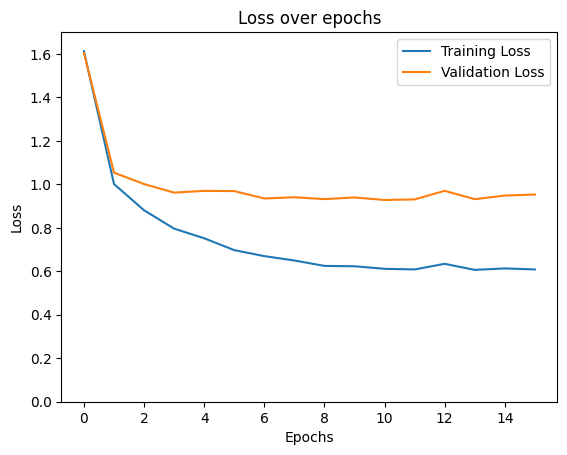

In [54]:
plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.ylim([0, 1.7])
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

**Plot Accuracies**

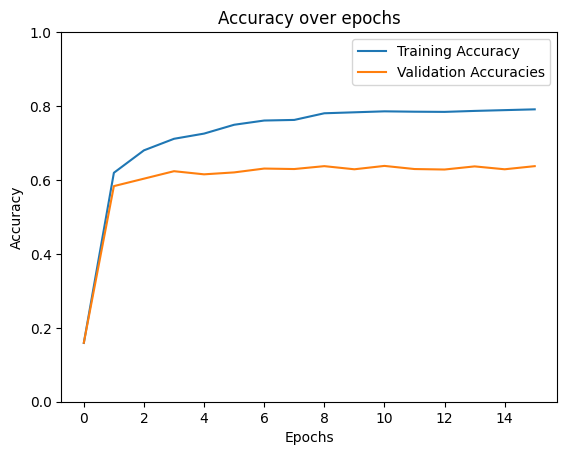

In [55]:
# Plot train accuracies, use label="Training Accuracy"
plt.plot(train_accuracies, label="Training Accuracy")
# Plot validation accuracies, use label="Validation Accuracy"
plt.plot(valid_accuracies, label="Validation Accuracies")
plt.ylim([0, 1])
plt.title("Accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();

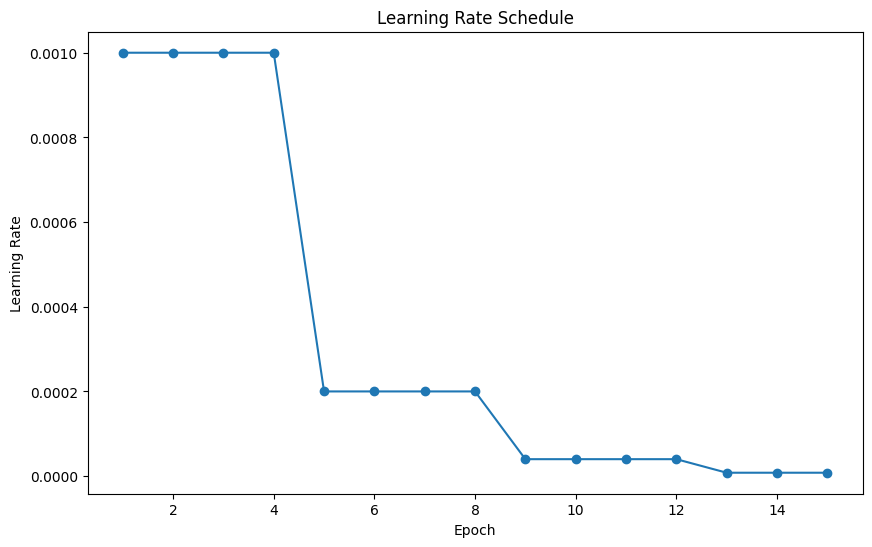

In [56]:
# Plot the learning rates
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), learning_rates, marker="o", label="Learning Rate")
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

**Loading the best Model saved**

In [58]:
checkpoint = torch.load("model/LR_model.pth", map_location=device)

# Load the state dictionaries
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

C:\Users\Asus\AppData\Local\Temp\ipykernel_1892\3109669559.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("model/LR_model.pth", map_location=dev

**Probabilities that the model predicts on the validation set**

In [59]:
from training import predict

probabilities_val = predict(model, val_loader, device)
predictions_val = torch.argmax(probabilities_val, dim=1)

print(predictions_val)

Predicting:   0%|          | 0/52 [00:00<?, ?it/s]

tensor([0, 4, 0,  ..., 2, 0, 1])


**Confusion Matrix**

Get Labels: 100%|██████████| 52/52 [00:20<00:00,  2.58it/s]


<Figure size 1000x800 with 0 Axes>

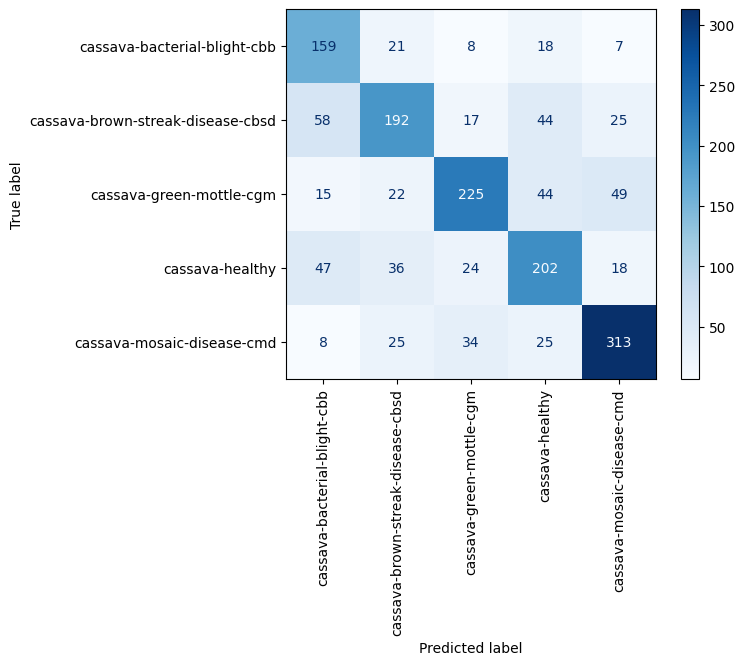

In [60]:
targets_val = torch.cat([labels for _, labels in tqdm(val_loader, desc="Get Labels")])

cm = confusion_matrix(targets_val.cpu(), predictions_val.cpu())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Set figure size
plt.figure(figsize=(10, 8))

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical");

### 5. Submission to Competition

In [61]:
test_dir = os.path.join('data_p2', 'test')

print(test_dir)

data_p2\test


The ```file_to_confidence``` file makes model predictions on a single image. The steps in the function are:
- Open the image.
- Apply our transformation pipeline to the image as our model expects.
-  Use unsqueeze to change the image tensor to 4D (1 X 3 X 224 X 224) as our model is expecting a batch of images.
- Place image on device we're using.
- Make prediction and pass it through a SoftMax to get probabilities (numbers between 0 and 1, that sum to 1). 
- Convert result to a DataFrame.

In [62]:
model.to(device)


def file_to_confidence(model, datadir, filename, transform_pipeline):
    file_path = os.path.join(datadir, filename)
    image = PIL.Image.open(file_path)
    transformed = transform_pipeline(image)
    unsqueezed = transformed.unsqueeze(0)
    image_cuda = unsqueezed.to(device)

    model.eval()
    with torch.no_grad():
        model_raw = model(image_cuda)
        confidence = torch.nn.functional.softmax(model_raw, dim=1)

    conf_df = pd.DataFrame([[filename] + confidence.tolist()[0]])
    conf_df.columns = ["ID"] + train_dataset.dataset.classes

    return conf_df